In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print("Path to dataset files:", path)

100%|██████████| 64.8k/64.8k [00:00<00:00, 443kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/versions/1


In [2]:
import os
print(os.listdir(path))

['tesla_deliveries_dataset_2015_2025.csv']


In [3]:
import pandas as pd
df = pd.read_csv(f"{path}/tesla_deliveries_dataset_2015_2025.csv")

In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [6]:
df.shape

(2640, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [11]:
for i in df:
  if df[i].dtype == 'object':
    print(f"olumn :{i}")
    print(df[i].value_counts().head())
    print("*"*100)

olumn :Region
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64
****************************************************************************************************
olumn :Model
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64
****************************************************************************************************
olumn :Source_Type
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64
****************************************************************************************************


# Visualization

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns



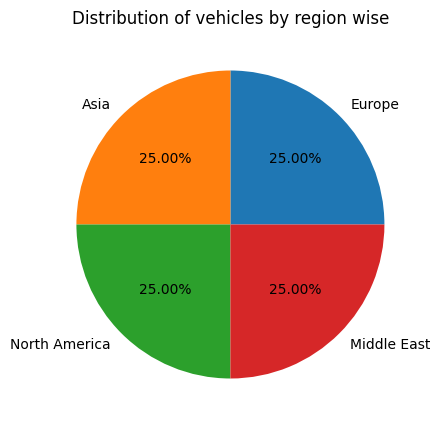

In [13]:
plt.figure(figsize=(10,5))
plt.pie(df["Region"].value_counts(),labels=df["Region"].value_counts().index,autopct="%0.2f%%")
plt.title("Distribution of vehicles by region wise")
plt.show()

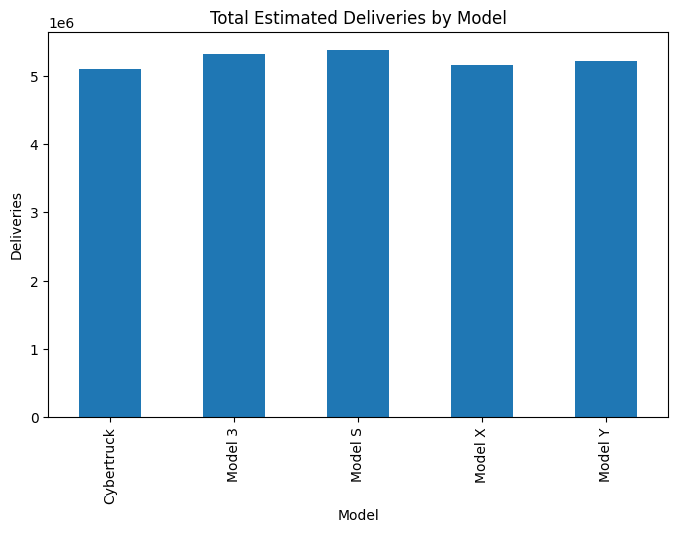

In [14]:

m = df.groupby("Model")["Estimated_Deliveries"].sum()

m.plot(kind="bar", figsize=(8,5))
plt.title("Total Estimated Deliveries by Model")
plt.ylabel("Deliveries")
plt.show()

In [15]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


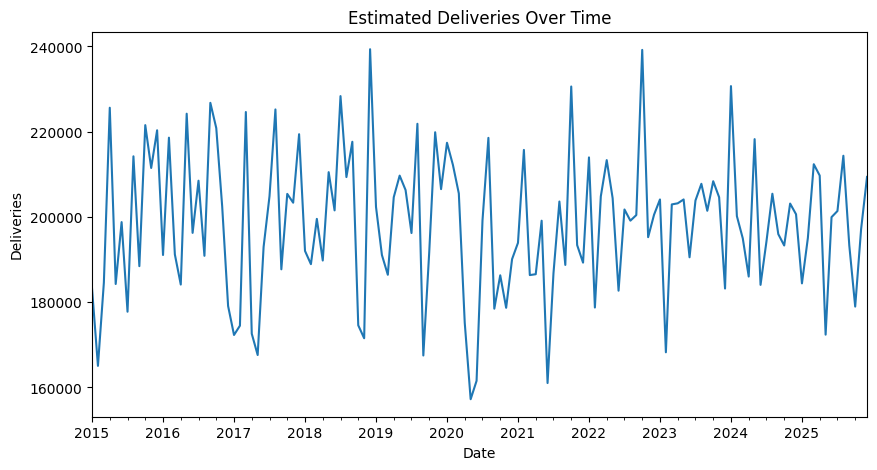

In [18]:
df["Date"] = pd.to_datetime(
    dict(year=df.Year, month=df.Month, day=1)
)

monthly = df.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))
monthly.plot()
plt.title("Estimated Deliveries Over Time")
plt.ylabel("Deliveries")
plt.show()

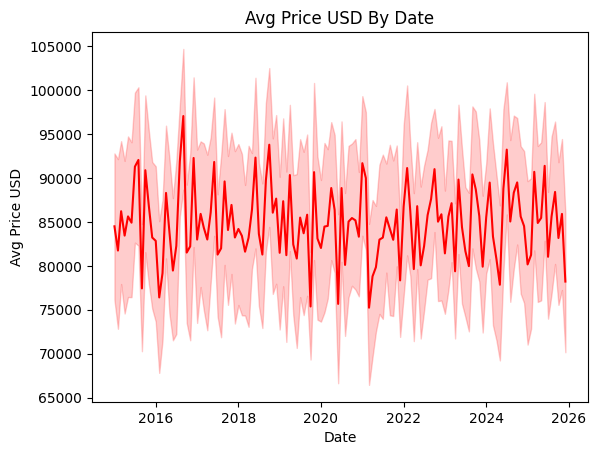

In [28]:
sns.lineplot(x='Date',y='Avg_Price_USD',data=df,color='red')
plt.xlabel('Date')
plt.ylabel('Avg Price USD')
plt.title('Avg Price USD By Date')
plt.show()

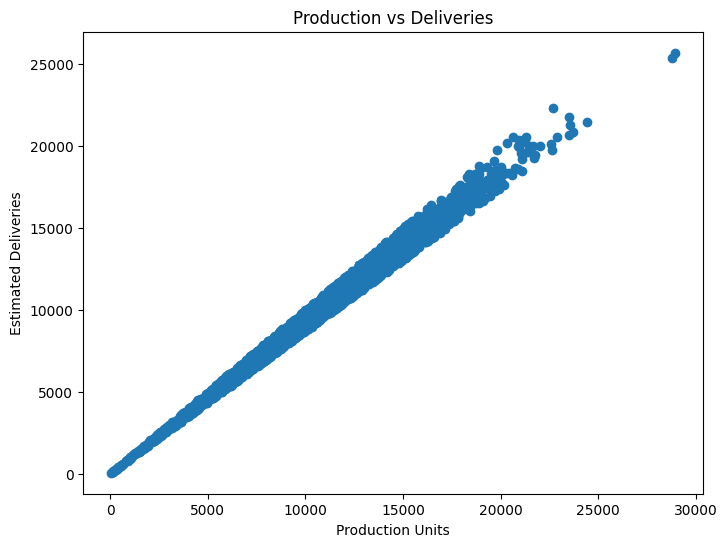

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Production_Units"],
    df["Estimated_Deliveries"],
    alpha=1
)

plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.title("Production vs Deliveries")
plt.show()

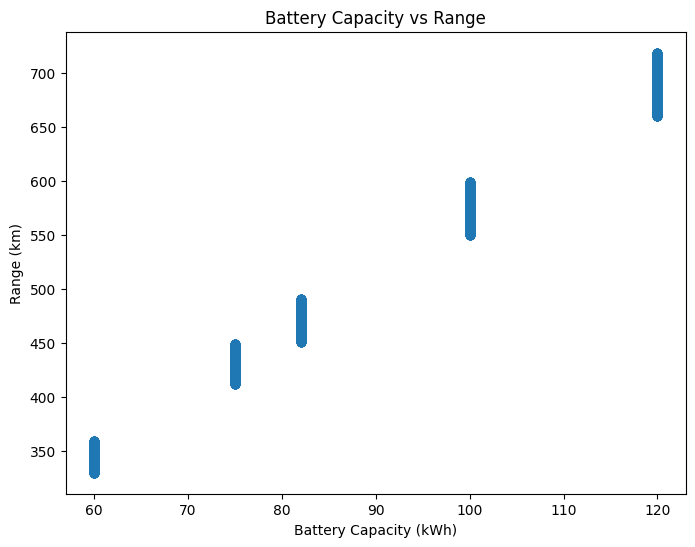

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Battery_Capacity_kWh"],
    df["Range_km"],
    alpha=1
)

plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")
plt.title("Battery Capacity vs Range")
plt.show()

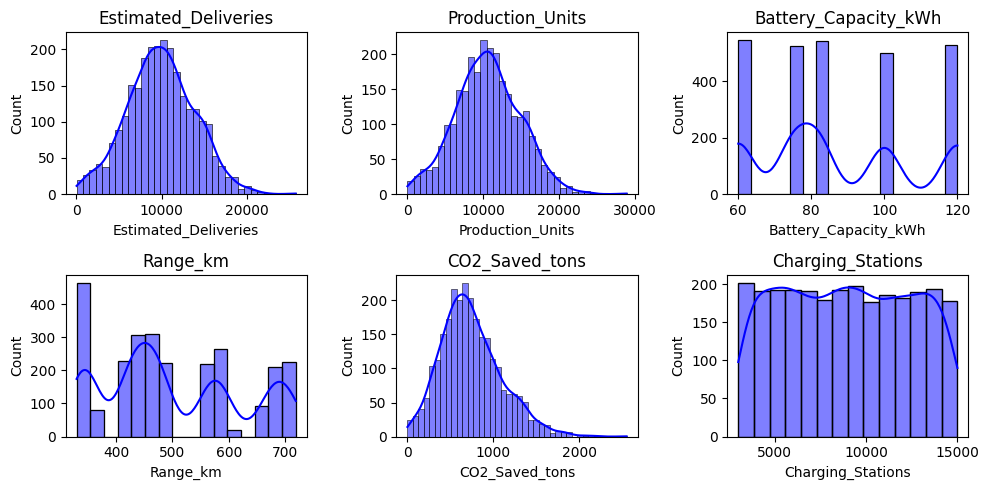

In [25]:
cols_hist = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,5))
for col in cols_hist:
    plt.subplot(2,3,cols_hist.index(col)+1)
    sns.histplot(df[col],kde=True,color='blue')
    plt.title(col)
plt.tight_layout()
plt.show()

# Outlier detection

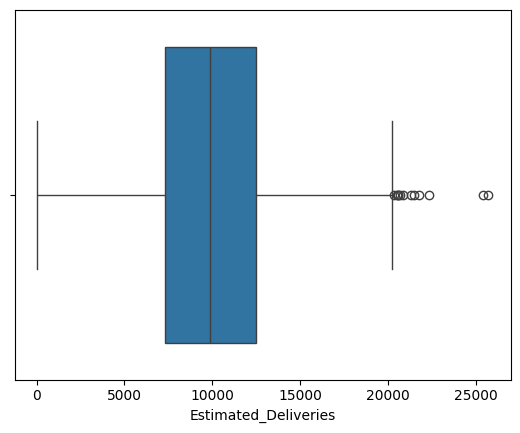

In [21]:
#Skewed distribution
sns.boxplot(x=df["Estimated_Deliveries"])
plt.show()

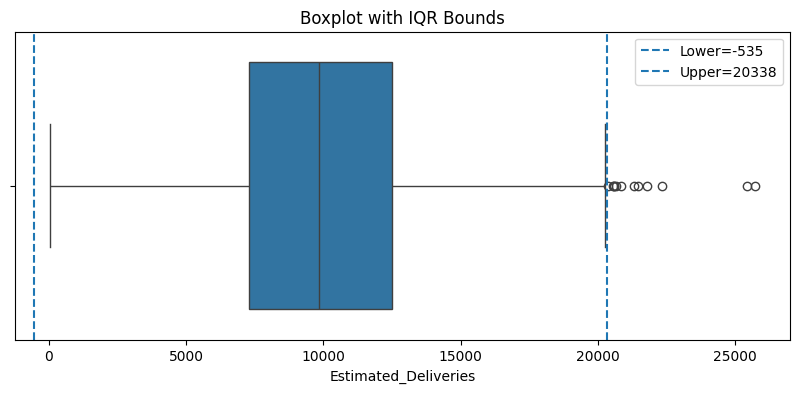

In [22]:
#Skewed distribution


Q1 = df["Estimated_Deliveries"].quantile(0.25)
Q3 = df["Estimated_Deliveries"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

plt.figure(figsize=(10,4))

sns.boxplot(x=df["Estimated_Deliveries"])

plt.axvline(lower, linestyle="--", label=f"Lower={lower:.0f}")
plt.axvline(upper, linestyle="--", label=f"Upper={upper:.0f}")

plt.legend()
plt.title("Boxplot with IQR Bounds")
plt.show()

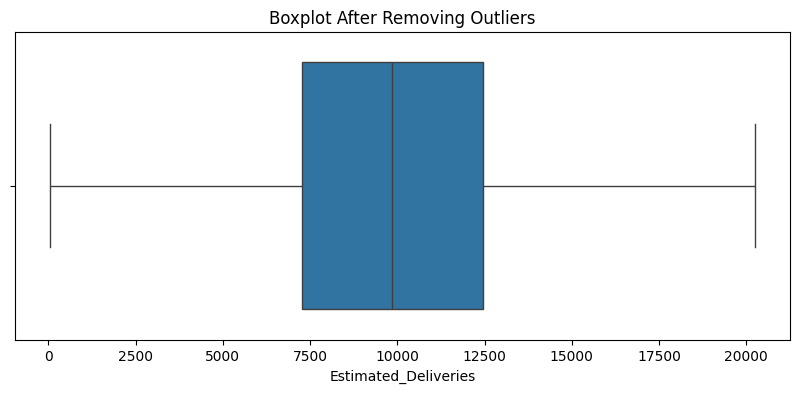

In [30]:
Q1 = df["Estimated_Deliveries"].quantile(0.25)
Q3 = df["Estimated_Deliveries"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_cleaned = df[(df["Estimated_Deliveries"] >= lower) & (df["Estimated_Deliveries"] <= upper)]

plt.figure(figsize=(10,4))
sns.boxplot(x=df_cleaned["Estimated_Deliveries"])
plt.title("Boxplot After Removing Outliers")
plt.show()


In [31]:
df_cleaned.shape

(2628, 13)

In [33]:
df_cleaned.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


# Model Building

In [32]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [36]:
df_sorted = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)

In [37]:
df_sorted.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Middle East,Model Y,10348,10835,85599.95,82,488,757.47,Estimated (Region),5991,2015-01-01
1,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2,2015,1,Europe,Model Y,10835,11723,62939.81,120,718,1166.93,Official (Quarter),12301,2015-01-01
3,2015,1,North America,Model X,8122,8343,62838.32,75,423,515.34,Official (Quarter),9297,2015-01-01
4,2015,1,Middle East,Model S,13902,15423,94629.02,75,445,927.96,Official (Quarter),8666,2015-01-01


In [38]:
correlation = df_sorted.select_dtypes(include=["number"]).corr()['Estimated_Deliveries'].sort_values(ascending=False)

print(correlation)

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


In [41]:
y = df_sorted['Estimated_Deliveries']

X = df_sorted.drop(columns=['Estimated_Deliveries'])

In [43]:
target_col = 'Estimated_Deliveries'
num_features = ['Year',  'Production_Units',
                'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                'CO2_Saved_tons', 'Charging_Stations']
cat_features = ['Region', 'Model']

X = df_sorted[num_features + cat_features]
y = df_sorted[target_col]

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

pipeline_framework = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()) \
])


In [45]:
split_idx = int(len(X) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [46]:
tscv = TimeSeriesSplit(n_splits=5)

In [47]:
param_grid = [
    {
        'regressor': [LinearRegression()],
        'regressor__fit_intercept': [True, False]
    },
    {
        'regressor': [RandomForestRegressor(random_state=42)],
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [10, 15, None],
        'regressor__min_samples_split': [2, 5]
    }
]

In [48]:
grid_search = GridSearchCV(
    estimator=pipeline_framework,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\n[SUCCESS] Pipeline Tuning and Selection Process Complete.")
print(f"Winning Architecture Settings: {grid_search.best_params_['regressor']}")


[SUCCESS] Pipeline Tuning and Selection Process Complete.
Winning Architecture Settings: LinearRegression()


In [50]:
import numpy as np
best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== FINAL EVALUATION REPORT (HOLDOUT WINDOW) ===")
print(f"Selected Model Type:            {type(best_pipeline.named_steps['regressor']).__name__}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE):      {mae:.2f}")
print(f"R² Fit Performance Score:       {r2:.4f}")
print(f"Best Hyperparameters:           {grid_search.best_params_}")

=== FINAL EVALUATION REPORT (HOLDOUT WINDOW) ===
Selected Model Type:            LinearRegression
Root Mean Squared Error (RMSE): 393.02
Mean Absolute Error (MAE):      321.53
R² Fit Performance Score:       0.9885
Best Hyperparameters:           {'regressor': LinearRegression(), 'regressor__fit_intercept': False}
